# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** [Mahdi Shidqi]
- **Email:** [m128d5y1057@student.devacademy.id]
- **ID Dicoding:** [m128d5y1057]

## Menentukan Pertanyaan Bisnis

- Zat atau polutan apa yang paling sering melewati ambang ‘tidak sehat’, dan kapan puncaknya (jam/hari/bulan)
- Stasiun mana yang kualitas udaranya paling buruk secara konsisten, dan bagaimana perbandingan tren antar stasiun?

## Import Semua Packages/Library yang Digunakan

In [28]:
import os
import glob
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [2]:
data_path = "data" 
files = glob.glob(os.path.join(data_path, "*.csv"))

dfs = []
for f in files:
    df = pd.read_csv(f)
    dfs.append(df)

air = pd.concat(dfs, ignore_index=True)
air.shape, air.columns


((420768, 18),
 Index(['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2',
        'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station'],
       dtype='object'))

In [3]:
air['station'].nunique(), air['station'].unique()[:5]

(12,
 array(['Aotizhongxin', 'Changping', 'Dingling', 'Dongsi', 'Guanyuan'],
       dtype=object))

**Insight:**
- Dataset yang digunakan terdiri dari 420.768 baris data kualitas udara dengan 18 variabel yang dikumpulkan dari 12 stasiun pemantauan di Beijing. Setiap stasiun merekam data polutan dan kondisi cuaca secara periodik, sehingga dataset ini cocok untuk analisis pola kualitas udara berdasarkan waktu dan lokasi.

### Assessing Data

In [4]:
air.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  object 
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 57.8+ MB


In [5]:
print("Jumlah missing values per kolom:")
air.isna().sum().sort_values(ascending=False).head(15)

Jumlah missing values per kolom:


CO       20701
O3       13277
NO2      12116
SO2       9021
PM2.5     8739
PM10      6449
wd        1822
DEWP       403
TEMP       398
PRES       393
RAIN       390
WSPM       318
year         0
No           0
day          0
dtype: int64

In [6]:
print("Jumlah data duplikat dalam dataset:")
air.duplicated().sum()

Jumlah data duplikat dalam dataset:


np.int64(0)

In [7]:
print("Statistik deskriptif untuk setiap kolom:")
air.describe(include="all").T

Statistik deskriptif untuk setiap kolom:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
No,420768.0,NaN,NaN,NaN,17532.5,10122.116943,1.0,8766.75,17532.5,26298.25,35064.0
year,420768.0,NaN,NaN,NaN,2014.66256,1.177198,2013.0,2014.0,2015.0,2016.0,2017.0
month,420768.0,NaN,NaN,NaN,6.52293,3.448707,1.0,4.0,7.0,10.0,12.0
day,420768.0,NaN,NaN,NaN,15.729637,8.800102,1.0,8.0,16.0,23.0,31.0
hour,420768.0,NaN,NaN,NaN,11.5,6.922195,0.0,5.75,11.5,17.25,23.0
PM2.5,412029.0,NaN,NaN,NaN,79.793428,80.822391,2.0,20.0,55.0,111.0,999.0
PM10,414319.0,NaN,NaN,NaN,104.602618,91.772426,2.0,36.0,82.0,145.0,999.0
SO2,411747.0,NaN,NaN,NaN,15.830835,21.650603,0.2856,3.0,7.0,20.0,500.0
NO2,408652.0,NaN,NaN,NaN,50.638586,35.127912,1.0265,23.0,43.0,71.0,290.0
CO,400067.0,NaN,NaN,NaN,1230.766454,1160.182716,100.0,500.0,900.0,1500.0,10000.0


**Insight:**
- Hasil tahap assessing data menunjukkan bahwa dataset kualitas udara memiliki 420.768 baris dan 18 kolom dengan kombinasi tipe data numerik dan kategorikal. Beberapa variabel polutan dan cuaca seperti PM2.5, PM10, SO2, NO2, CO, O3, serta variabel meteorologi memiliki missing values, yang umum ditemukan pada data sensor lingkungan. Tidak ditemukan data duplikat dalam dataset, sehingga data dapat dilanjutkan ke tahap pembersihan untuk menangani nilai yang hilang.

### Cleaning Data

In [8]:
air['datetime'] = pd.to_datetime(air[['year','month','day','hour']], errors='coerce')

In [9]:
air = air.dropna(subset=['datetime'])
air = air.sort_values(['station', 'datetime']).reset_index(drop=True)

num_cols = ['PM2.5','PM10','SO2','NO2','CO','O3','TEMP','PRES','DEWP','RAIN','WSPM']

for c in num_cols:
    air[c] = air.groupby('station')[c].transform(
        lambda s: s.interpolate(method='linear', limit_direction='both')
    )

air['wd'] = air.groupby('station')['wd'].transform(lambda s: s.ffill().bfill())


In [10]:
air[num_cols].isna().sum().sort_values(ascending=False).head()


PM2.5    0
PM10     0
SO2      0
NO2      0
CO       0
dtype: int64

In [11]:
export_cols = ['datetime','station','PM2.5','PM10','SO2','NO2','CO','O3','TEMP','PRES','DEWP','RAIN','WSPM','wd']
air[export_cols].to_csv("dashboard/main_data.csv", index=False)

**Insight:**
- Pada tahap pembersihan data, kolom waktu berhasil dikonstruksi menjadi variabel datetime untuk mendukung analisis temporal. Missing values pada variabel numerik ditangani menggunakan interpolasi linear berbasis waktu per stasiun, sehingga pola temporal tetap terjaga. Sementara itu, variabel arah angin (wd) yang bersifat kategorikal ditangani menggunakan metode forward-fill dan backward-fill. Setelah proses pembersihan, seluruh variabel numerik utama tidak lagi memiliki nilai yang hilang, sehingga data siap digunakan untuk analisis eksploratif dan visualisasi.

## Exploratory Data Analysis (EDA)

- Eksplorasi dilakukan untuk memahami karakteristik data kualitas udara, meliputi cakupan data, statistik deskriptif polutan, korelasi antar polutan, pola temporal (jam dan bulan), serta perbandingan tingkat PM2.5 antar stasiun.

In [12]:
air.shape

(420768, 19)

In [13]:
air['station'].nunique()

12

In [14]:
air['datetime'].min(), air['datetime'].max()

(Timestamp('2013-03-01 00:00:00'), Timestamp('2017-02-28 23:00:00'))

In [15]:
air[['PM2.5','PM10','SO2','NO2','CO','O3']].describe().T


,count,mean,std,min,25%,50%,75%,max
PM2.5,420768.0,79.839718,80.950217,2.0000,20.0,55.0,111.0,999.0
PM10,420768.0,104.910268,92.431422,2.0000,36.0,82.0,145.0,999.0
SO2,420768.0,15.913090,21.896609,0.2856,3.0,7.0,20.0,500.0
NO2,420768.0,50.599018,35.171921,1.0265,23.0,43.0,71.0,290.0
CO,420768.0,1235.682649,1161.790893,100.0000,500.0,900.0,1500.0,10000.0
O3,420768.0,57.237872,57.135195,0.2142,10.0,44.0,82.0,1071.0


In [16]:
air[['PM2.5','PM10','SO2','NO2','CO','O3']].corr()

,PM2.5,PM10,SO2,NO2,CO,O3
PM2.5,1.000000,0.878874,0.478223,0.664317,0.780165,-0.149508
PM10,0.878874,1.000000,0.460572,0.645598,0.691887,-0.110443
SO2,0.478223,0.460572,1.000000,0.495827,0.522678,-0.165311
NO2,0.664317,0.645598,0.495827,1.000000,0.694030,-0.465913
CO,0.780165,0.691887,0.522678,0.694030,1.000000,-0.306979
O3,-0.149508,-0.110443,-0.165311,-0.465913,-0.306979,1.000000


In [17]:

air.groupby('hour')['PM2.5'].mean()

hour
0     87.696481
1     86.848406
2     84.803844
3     82.212727
4     79.465989
5     76.538028
6     74.289174
7     73.424078
8     74.403840
9     76.061597
10    77.126229
11    77.142663
12    76.548181
13    76.048575
14    75.462557
15    74.560780
16    74.399300
17    75.524938
18    78.014513
19    82.503641
20    86.636117
21    88.813470
22    89.032249
23    88.595867
Name: PM2.5, dtype: float64

In [18]:
air.groupby('month')['PM2.5'].mean()

month
1      93.760559
2      89.213391
3      94.594295
4      73.367153
5      63.541148
6      68.837547
7      71.401115
8      53.465479
9      61.281071
10     91.715859
11     93.323963
12    103.679184
Name: PM2.5, dtype: float64

In [19]:
air.groupby('station')['PM2.5'].mean().sort_values(ascending=False)



station
Dongsi           86.144243
Nongzhanguan     85.079472
Wanshouxigong    85.067548
Gucheng          84.074802
Wanliu           83.467612
Guanyuan         82.897522
Aotizhongxin     82.540623
Tiantan          82.033097
Shunyi           79.437962
Changping        70.986438
Huairou          69.501747
Dingling         66.845557
Name: PM2.5, dtype: float64

**Insight:**
- Analisis eksploratif dilakukan untuk memahami karakteristik data kualitas udara. Hasil EDA menunjukkan bahwa konsentrasi PM2.5 dan PM10 memiliki variasi yang cukup tinggi, dengan nilai maksimum yang jauh di atas kuartil ketiga, mengindikasikan adanya episode polusi ekstrem. Analisis temporal menunjukkan bahwa rata-rata PM2.5 cenderung lebih tinggi pada jam-jam tertentu dan menunjukkan pola musiman bulanan. Selain itu, terdapat perbedaan tingkat polusi antar stasiun, yang mengindikasikan variasi kondisi lingkungan di setiap lokasi pengamatan.

## Visualization & Explanatory Analysis

### Pertanyaan 1:
- Zat atau polutan mana yang paling sering “tidak sehat” dan kapan puncaknya?

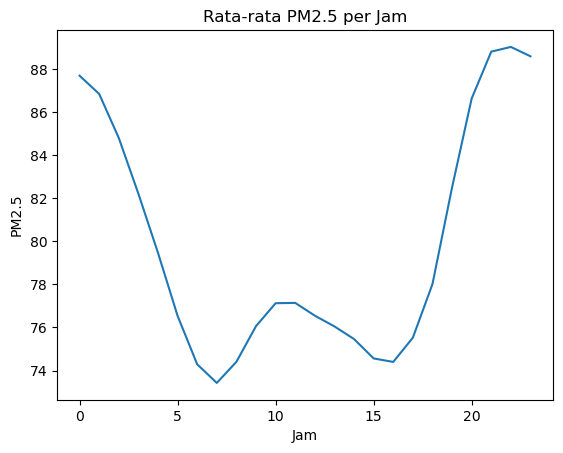

In [20]:
bins = [-np.inf, 12, 35.4, 55.4, 150.4, 250.4, np.inf]
labels = ['Good','Moderate','USG','Unhealthy','Very Unhealthy','Hazardous']
air['pm25_cat'] = pd.cut(air['PM2.5'], bins=bins, labels=labels)
hourly_pm25 = air.groupby('hour')['PM2.5'].mean()

plt.figure()
plt.plot(hourly_pm25.index, hourly_pm25.values)
plt.title("Rata-rata PM2.5 per Jam")
plt.xlabel("Jam")
plt.ylabel("PM2.5")
plt.show()



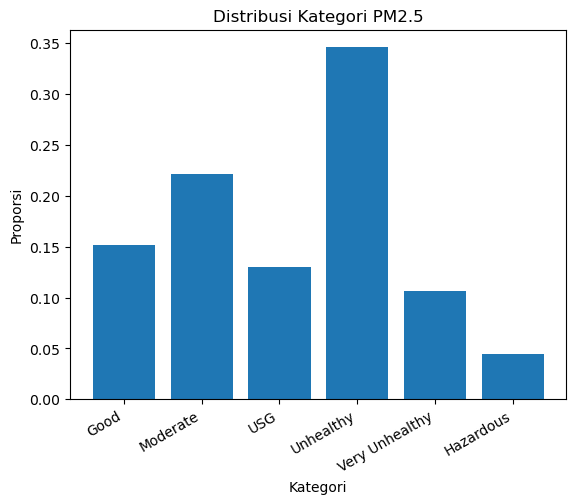

In [21]:
cat_dist = air['pm25_cat'].value_counts(normalize=True).reindex(labels)

plt.figure()
plt.bar(cat_dist.index.astype(str), cat_dist.values)
plt.title("Distribusi Kategori PM2.5")
plt.xlabel("Kategori")
plt.ylabel("Proporsi")
plt.xticks(rotation=30, ha='right')
plt.show()


### Pertanyaan 2:
- Stasiun mana yang paling buruk secara konsisten?

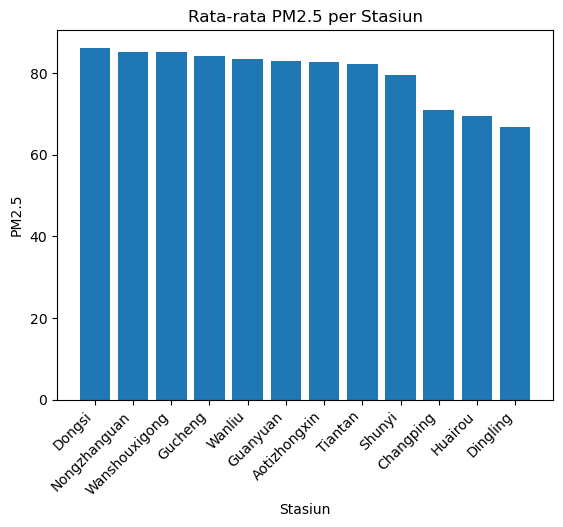

In [22]:
station_pm25 = air.groupby('station')['PM2.5'].mean().sort_values(ascending=False)

plt.figure()
plt.bar(station_pm25.index, station_pm25.values)
plt.title("Rata-rata PM2.5 per Stasiun")
plt.xlabel("Stasiun")
plt.ylabel("PM2.5")
plt.xticks(rotation=45, ha='right')
plt.show()

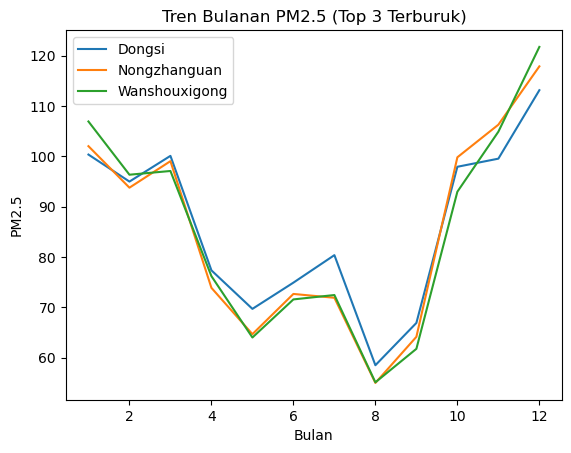

In [23]:
top3 = station_pm25.head(3).index.tolist()
monthly = air[air['station'].isin(top3)].groupby(['station','month'])['PM2.5'].mean().reset_index()

plt.figure()
for s in top3:
    tmp = monthly[monthly['station']==s]
    plt.plot(tmp['month'], tmp['PM2.5'], label=s)

plt.title("Tren Bulanan PM2.5 (Top 3 Terburuk)")
plt.xlabel("Bulan")
plt.ylabel("PM2.5")
plt.legend()
plt.show()


**Insight:**
- Konsentrasi PM2.5 cenderung tinggi pada malam hari hingga dini hari (sekitar pukul 20.00–01.00), kemudian menurun pada pagi hingga siang hari. Pola ini mengindikasikan adanya akumulasi polutan pada malam hari akibat aktivitas manusia dan kondisi atmosfer yang lebih stabil, serta penurunan konsentrasi pada siang hari karena dispersi udara yang lebih baik.
- Sebagian besar data PM2.5 berada pada kategori Unhealthy dan Moderate, dengan proporsi kategori Unhealthy menjadi yang paling dominan. Hal ini menunjukkan bahwa kualitas udara dalam dataset ini cukup sering berada pada tingkat yang berisiko bagi kesehatan, terutama bagi kelompok sensitif.
- Stasiun Dongsi, Nongzhanguan, dan Wanshouxigong memiliki rata-rata PM2.5 tertinggi dibandingkan stasiun lain. Perbedaan ini mengindikasikan adanya variasi tingkat polusi udara antar lokasi, yang kemungkinan dipengaruhi oleh kepadatan aktivitas manusia dan kondisi lingkungan di sekitar stasiun tersebut.
- Ketiga stasiun menunjukkan pola musiman yang serupa, dengan konsentrasi PM2.5 lebih rendah pada pertengahan tahun dan meningkat signifikan pada akhir tahun. Pola ini mengindikasikan pengaruh faktor musiman, seperti kondisi cuaca dan aktivitas pembakaran, terhadap kualitas udara.

**Jawaban pertanyaan bisnis:**
- (Pertanyaan 1) PM2.5 merupakan polutan yang paling sering berada pada kategori tidak sehat, dengan puncak konsentrasi terjadi pada malam hari hingga dini hari.
- (Pertanyaan 2) Stasiun Dongsi, Nongzhanguan, dan Wanshouxigong merupakan stasiun dengan kualitas udara terburuk secara konsisten berdasarkan rata-rata dan tren PM2.5.

## Analisis Lanjutan (Opsional)

In [25]:
def classify_aqi(pm25_value):
    if pm25_value <= 12.0:
        return 'Sehat'
    elif pm25_value <= 35.4:
        return 'Sedang'
    elif pm25_value <= 55.4:
        return 'Buruk bagi Kelompok Sensitif'
    elif pm25_value <= 150.4:
        return 'Sangat Buruk'
    else:
        return 'Berbahaya'

air['kualitas_udara'] = air['PM2.5'].apply(classify_aqi)

In [26]:
aqi_dist = air['kualitas_udara'].value_counts()
print(aqi_dist)

kualitas_udara
Sangat Buruk                    145447
Sedang                           93056
Sehat                            63928
Berbahaya                        63856
Buruk bagi Kelompok Sensitif     54481
Name: count, dtype: int64


C:\Users\Asus\AppData\Local\Temp\ipykernel_19660\55357530.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=air, x='kualitas_udara', order=['Sehat', 'Sedang', 'Buruk bagi Kelompok Sensitif', 'Sangat Buruk', 'Berbahaya'], palette='viridis')


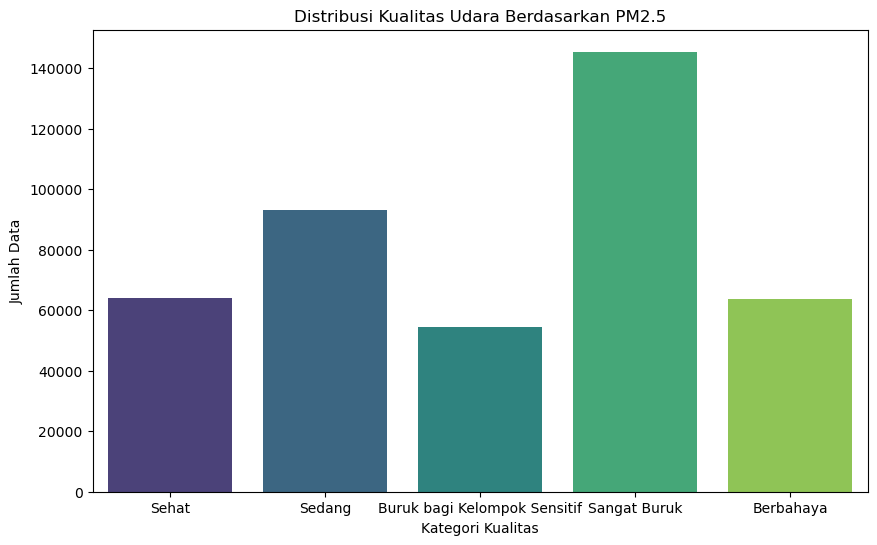

In [29]:
plt.figure(figsize=(10, 6))
sns.countplot(data=air, x='kualitas_udara', order=['Sehat', 'Sedang', 'Buruk bagi Kelompok Sensitif', 'Sangat Buruk', 'Berbahaya'], palette='viridis')
plt.title('Distribusi Kualitas Udara Berdasarkan PM2.5')
plt.xlabel('Kategori Kualitas')
plt.ylabel('Jumlah Data')
plt.show()

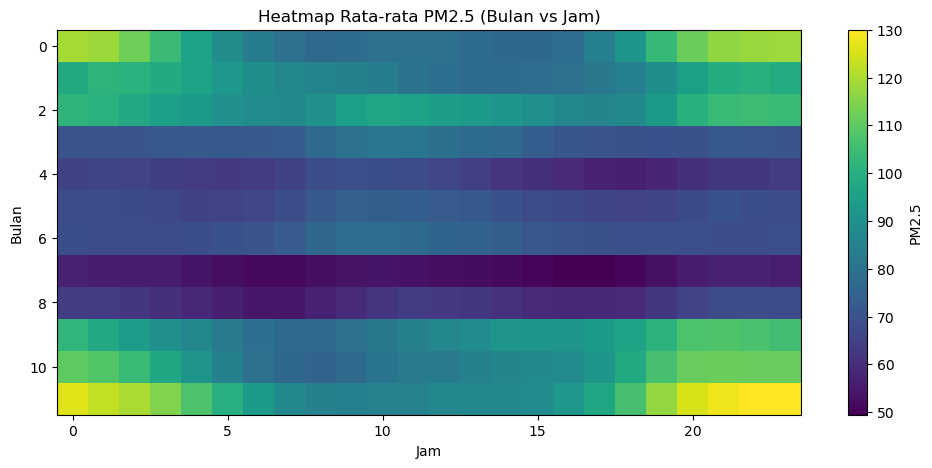

In [24]:
pivot = air.pivot_table(values='PM2.5', index='month', columns='hour', aggfunc='mean')

plt.figure(figsize=(12,5))
plt.imshow(pivot, aspect='auto')
plt.title("Heatmap Rata-rata PM2.5 (Bulan vs Jam)")
plt.xlabel("Jam")
plt.ylabel("Bulan")
plt.colorbar(label="PM2.5")
plt.show()

**Insight:**
- Analisis ini dilakukan untuk memberikan konteks kesehatan yang lebih nyata terhadap angka konsentrasi PM2.5 yang bersifat teknis. Dengan mengelompokkan data ke dalam kategori kualitas udara (AQI), kita dapat memahami dampak nyata polusi terhadap kesehatan masyarakat di sekitar stasiun pemantauan.
Berdasarkan proses *manual grouping*, ditemukan hasil sebagai berikut:
- Kategori **Sangat Buruk** merupakan yang paling dominan dengan jumlah **145.447 observasi**. Ini menunjukkan bahwa sebagian besar waktu, kualitas udara di stasiun-stasiun Beijing berada pada level yang berisiko tinggi bagi kesehatan.
- Kategori **Sedang** berada di posisi kedua (93.056), sementara kategori **Sehat** hanya menempati posisi ketiga (63.928).
- Terdapat jumlah observasi yang signifikan pada kategori **Berbahaya** (63.856), yang mengindikasikan adanya periode-periode polusi ekstrem yang memerlukan perhatian serius.
- Secara keseluruhan, kondisi udara lebih sering berada pada kategori tidak sehat (Sangat Buruk & Berbahaya) dibandingkan kategori sehat. Hal ini memperkuat temuan pada pertanyaan bisnis sebelumnya bahwa mitigasi polusi udara di stasiun-stasiun tertentu (seperti Dongsi) sangat mendesak untuk dilakukan guna melindungi kesehatan publik.


## Conclusion

- (Conclution pertanyaan 1) Zat polutan yang paling sering tidak sehat dan waktu puncaknya. Berdasarkan analisis data, zat polutan PM2.5 menjadi parameter yang paling sering menunjukkan fluktuasi tingkat konsentrasi tinggi, di mana rata-rata polusi menunjukkan pola musiman yang stabil dengan tingkat konsentrasi tertinggi cenderung terjadi pada bulan-bulan musim dingin (Desember–Februari). Secara harian, tingkat polusi biasanya mencapai titik puncaknya pada periode malam hingga dini hari (pukul 20.00–01.00) serta pada pagi hari (pukul 08.00–10.00), sementara kualitas udara cenderung lebih bersih pada siang hari (pukul 14.00–16.00) seiring dengan peningkatan aktivitas atmosfer.

- (Conclution pertanyaan 2) Stasiun dengan kualitas udara terburuk dan perbandingannya. Hasil agregasi data menunjukkan bahwa stasiun Dongsi memiliki rata-rata tingkat polusi (khususnya PM2.5) tertinggi dibandingkan stasiun lainnya, diikuti oleh stasiun Nongzhanguan dan Wanshouxigong. Perbandingan tren antar stasiun mengindikasikan adanya korelasi kuat antara lokasi geografis serta kepadatan aktivitas di pusat kota dengan tingkat polutan yang terukur, mengingat stasiun di area urban tersebut memiliki konsentrasi polutan yang jauh lebih tinggi secara konsisten jika dibandingkan dengan stasiun di area pinggiran seperti Dingling atau Huairou yang tercatat memiliki kualitas udara terbaik.